# NB06 — H3: Horizon × warming interaction

**H3**: Organic and mineral horizons respond to warming with different functional categories — organic horizon shifts in C-cycling KOs; mineral horizon shifts in N-cycling and mineral-associated metabolism KOs.

Use the per-KO DA tables built in NB05 (DNA pool, both horizons). For each KO we have heated-vs-control log2 fold change in organic and in mineral. We can:
1. Compare the per-KO log2 FC distributions (organic vs mineral) — Pearson correlation, alignment.
2. Identify KOs with horizon-specific responses: significant in one but not the other, or different sign.
3. Test whether these horizon-specific KOs are enriched in C-cycling, peptidase, or other curated categories.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact, pearsonr, spearmanr

DATA_DIR = os.path.abspath('../data')
FIG_DIR  = os.path.abspath('../figures')
USER_DIR = os.path.abspath('../user_data')

DA = pd.read_csv(os.path.join(DATA_DIR, '05_da_per_ko_per_pool_per_horizon.tsv.gz'),
                  sep='\t', compression='gzip')
c_kos = pd.read_csv(os.path.join(USER_DIR, 'c_cycling_kos.tsv'), sep='\t')
print(f'DA rows: {len(DA):,}')
print(DA.groupby(['pool', 'horizon']).size())

DA rows: 54,330
pool  horizon
DNA   mineral    12863
      organic    12863
RNA   mineral    14302
      organic    14302
dtype: int64


## 1. Per-KO log2 FC organic vs mineral — DNA pool

Pivot DA so each row is a KO with two columns: log2_fc_organic, log2_fc_mineral. Compute correlation.

In [2]:
def horizon_pivot(DA, pool):
    sub = DA[DA['pool'] == pool]
    pivot = sub.pivot_table(index='ko', columns='horizon',
                            values=['log2_fc', 'p', 'q'], aggfunc='first')
    # Flatten columns
    pivot.columns = ['_'.join(c) for c in pivot.columns]
    pivot = pivot.dropna(subset=['log2_fc_mineral', 'log2_fc_organic'])
    return pivot.reset_index()

DNA_h = horizon_pivot(DA, 'DNA')
RNA_h = horizon_pivot(DA, 'RNA')
print(f'DNA KOs with both horizons: {len(DNA_h):,}')
print(f'RNA KOs with both horizons: {len(RNA_h):,}')
DNA_h.head()

DNA KOs with both horizons: 12,863
RNA KOs with both horizons: 14,302


,ko,log2_fc_mineral,log2_fc_organic,p_mineral,p_organic,q_mineral,q_organic
0,K00001,0.123162,0.097568,0.033193,0.222533,0.285887,0.613302
1,K00002,-0.472388,-0.477573,0.031565,0.002088,0.281325,0.069259
2,K00003,0.016974,-0.024045,0.605937,0.517766,0.790986,0.757311
3,K00004,-0.025434,0.035383,0.692699,0.556555,0.847056,0.781412
4,K00005,-0.243388,-0.109046,0.206109,0.547866,0.528528,0.777097


In [3]:
# Pearson and Spearman correlation of log2 FC across KOs (organic vs mineral)
for label, df in [('DNA', DNA_h), ('RNA', RNA_h)]:
    finite_mask = (np.isfinite(df['log2_fc_organic'].values) &
                   np.isfinite(df['log2_fc_mineral'].values))
    sub = df[finite_mask]
    pr, p_pr = pearsonr(sub['log2_fc_mineral'], sub['log2_fc_organic'])
    sr, p_sr = spearmanr(sub['log2_fc_mineral'], sub['log2_fc_organic'])
    print(f'{label}: n={len(sub):,}  Pearson={pr:.3f} (p={p_pr:.2e})  Spearman={sr:.3f} (p={p_sr:.2e})')

DNA: n=12,863  Pearson=0.075 (p=1.78e-17)  Spearman=0.216 (p=2.04e-135)
RNA: n=14,302  Pearson=0.034 (p=6.05e-05)  Spearman=0.120 (p=3.55e-47)


## 2. Horizon-specific responders

Define horizon-specific responders as KOs where:
- |log2_fc| > 0.3 in one horizon AND |log2_fc| < 0.1 in the other, OR
- log2_fc is positive in one and negative in the other (sign flip), with |log2_fc| > 0.3 in at least one.

Compute these for both DNA and RNA pools.

In [4]:
def classify_response(row, fc_thr=0.3, low_thr=0.1):
    o = row['log2_fc_organic']
    m = row['log2_fc_mineral']
    sign_flip = (o * m < 0)
    organic_only = (abs(o) >= fc_thr) and (abs(m) <= low_thr)
    mineral_only = (abs(m) >= fc_thr) and (abs(o) <= low_thr)
    big_either   = max(abs(o), abs(m)) >= fc_thr
    if sign_flip and big_either:
        return 'sign_flip'
    if organic_only:
        return 'organic_only'
    if mineral_only:
        return 'mineral_only'
    if abs(o) >= fc_thr and abs(m) >= fc_thr:
        if (o > 0 and m > 0):
            return 'both_up'
        if (o < 0 and m < 0):
            return 'both_down'
    return 'neither_or_small'

DNA_h['class'] = DNA_h.apply(classify_response, axis=1)
RNA_h['class'] = RNA_h.apply(classify_response, axis=1)
for label, df in [('DNA', DNA_h), ('RNA', RNA_h)]:
    print(f'\n{label} response classes:')
    print(df['class'].value_counts())


DNA response classes:
class
neither_or_small    5575
sign_flip           2590
organic_only        1416
both_up             1227
both_down           1085
mineral_only         970
Name: count, dtype: int64

RNA response classes:
class
neither_or_small    4463
sign_flip           3810
organic_only        2070
both_down           1547
both_up             1526
mineral_only         886
Name: count, dtype: int64


## 3. Are horizon-specific responses enriched in C-cycling KOs?

In [5]:
c_set = set(c_kos['ko'])
rows = []
for label, df in [('DNA', DNA_h), ('RNA', RNA_h)]:
    for cls in ['organic_only', 'mineral_only', 'sign_flip', 'both_up', 'both_down']:
        cls_kos = df[df['class'] == cls]['ko']
        n_total = len(df)
        n_cls   = len(cls_kos)
        n_c_in_cls = cls_kos.isin(c_set).sum()
        n_c_total  = df['ko'].isin(c_set).sum()
        if n_cls == 0 or n_c_total == 0:
            continue
        # 2x2: rows = (in class, not in class); cols = (C-cycling, other)
        n_o_in_cls = n_cls - n_c_in_cls
        n_o_total  = n_total - n_c_total
        n_c_not    = n_c_total - n_c_in_cls
        n_o_not    = n_o_total - n_o_in_cls
        OR, p = fisher_exact([[n_c_in_cls, n_c_not], [n_o_in_cls, n_o_not]],
                              alternative='greater')
        rows.append({'pool': label, 'class': cls,
                      'n_class': n_cls, 'n_c_in_class': int(n_c_in_cls),
                      'n_c_total': int(n_c_total), 'OR': OR, 'p': p})
interaction_enrich = pd.DataFrame(rows)
print(interaction_enrich.to_string(index=False))

pool        class  n_class  n_c_in_class  n_c_total       OR        p
 DNA organic_only     1416             2         57 0.292966 0.989674
 DNA mineral_only      970             1         57 0.218137 0.988658
 DNA    sign_flip     2590             2         57 0.143572 0.999959
 DNA      both_up     1227             7         57 1.329541 0.299232
 DNA    both_down     1085             0         57 0.000000 1.000000
 RNA organic_only     2070             1         57 0.105089 0.999868
 RNA mineral_only      886             2         57 0.549609 0.876085
 RNA    sign_flip     3810             6         57 0.322911 0.999265
 RNA      both_up     1526             4         57 0.630898 0.870980
 RNA    both_down     1547             0         57 0.000000 1.000000


## 4. Top horizon-specific KOs by class (DNA pool)

In [6]:
for cls in ['organic_only', 'mineral_only', 'sign_flip']:
    sub = DNA_h[DNA_h['class'] == cls]
    sub = sub.sort_values(['log2_fc_organic', 'log2_fc_mineral'],
                          key=lambda s: -s.abs(), ascending=True)
    print(f'\n=== DNA pool, class = {cls} (n={len(sub)}) — top 10 by |effect| ===')
    show_cols = ['ko', 'log2_fc_organic', 'log2_fc_mineral', 'p_organic', 'p_mineral']
    sub_top = sub.head(10).copy()
    sub_top['is_c'] = sub_top['ko'].isin(c_set)
    print(sub_top[show_cols + ['is_c']].to_string(index=False))


=== DNA pool, class = organic_only (n=1416) — top 10 by |effect| ===
    ko  log2_fc_organic  log2_fc_mineral  p_organic  p_mineral  is_c
K13367         8.805148         0.000000   0.135086        NaN False
K06009         8.768951         0.000000   0.173003        NaN False
K22659         8.558348         0.000000   0.241765        NaN False
K11647         8.548092         0.052815   0.036234   0.982102 False
K09666         8.378999         0.000000   0.103506        NaN False
K12301         8.352971         0.000000   0.042213        NaN False
K21396         8.290506         0.000000   0.001017        NaN False
K05052         8.077492         0.000000   0.114345        NaN False
K05760         8.063313         0.000000   0.008329        NaN False
K15387        -8.046971         0.000000   0.233715        NaN False

=== DNA pool, class = mineral_only (n=970) — top 10 by |effect| ===
    ko  log2_fc_organic  log2_fc_mineral  p_organic  p_mineral  is_c
K18278        -0.099910        -0


=== DNA pool, class = sign_flip (n=2590) — top 10 by |effect| ===
    ko  log2_fc_organic  log2_fc_mineral  p_organic  p_mineral  is_c
K07719         9.174704        -1.478782   0.003922   0.433664 False
K17647         9.020448        -0.296184   0.035946   0.777102 False
K09485         8.820454        -5.949844   0.055987   0.355918 False
K24155         8.520365        -0.188435   0.024738   0.937857 False
K01360         8.471419        -0.178736   0.149727   0.900980 False
K06058         8.312657        -5.602041   0.137633   0.355918 False
K01308         8.265454        -1.548320   0.037576   0.275579 False
K24689        -8.193445         0.364840   0.103654   0.816558 False
K17914         8.012104        -5.949844   0.042394   0.355918 False
K02507        -7.969057         0.110849   0.045286   0.962417 False


## 5. Scatter plot: log2 FC organic vs mineral

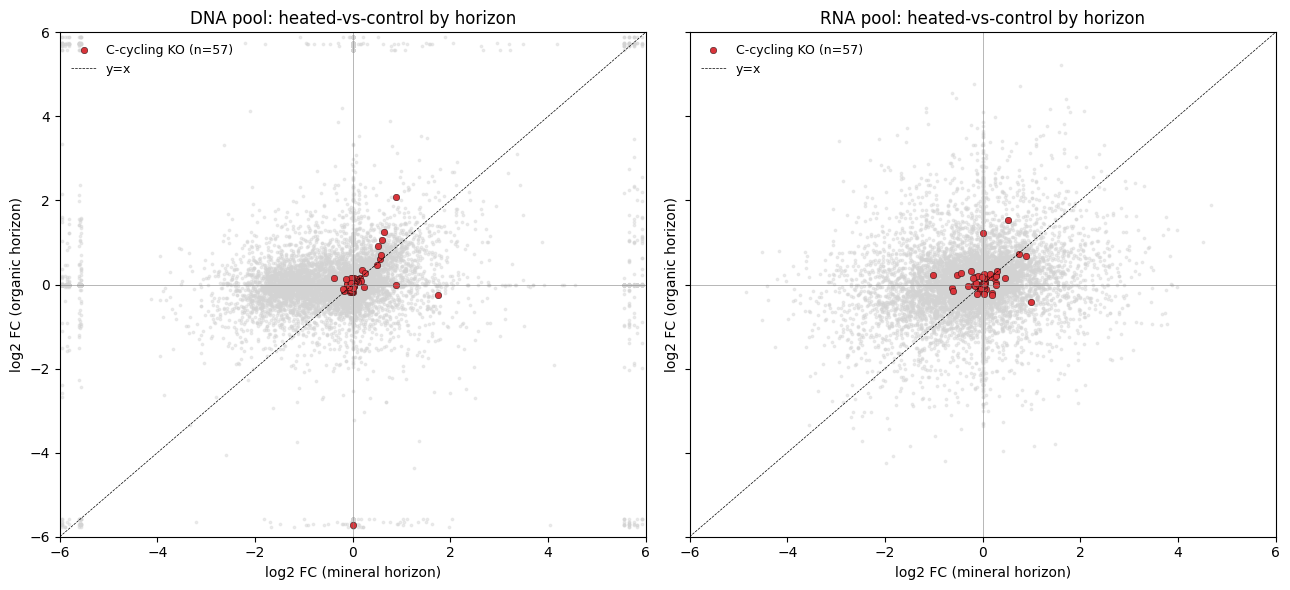

Wrote /home/cmungall/BERIL-research-observatory/projects/harvard_forest_warming/figures/06_horizon_interaction.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)
for ax, df, label in [(axes[0], DNA_h, 'DNA'), (axes[1], RNA_h, 'RNA')]:
    is_c = df['ko'].isin(c_set)
    ax.scatter(df.loc[~is_c, 'log2_fc_mineral'], df.loc[~is_c, 'log2_fc_organic'],
                s=3, color='lightgray', alpha=0.4, rasterized=True)
    ax.scatter(df.loc[is_c, 'log2_fc_mineral'], df.loc[is_c, 'log2_fc_organic'],
                s=22, color='#d9343a', edgecolors='black', linewidths=0.3,
                label=f'C-cycling KO (n={int(is_c.sum())})')
    # Reference lines
    lim = max(df[['log2_fc_organic', 'log2_fc_mineral']].abs().max().max(), 0.5)
    lim = min(lim, 6)
    ax.plot([-lim, lim], [-lim, lim], color='black', linewidth=0.5, linestyle='--', label='y=x')
    ax.axhline(0, color='gray', linewidth=0.4)
    ax.axvline(0, color='gray', linewidth=0.4)
    ax.set_xlabel('log2 FC (mineral horizon)')
    ax.set_ylabel('log2 FC (organic horizon)')
    ax.set_title(f'{label} pool: heated-vs-control by horizon')
    ax.legend(frameon=False, fontsize=9, loc='upper left')
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
plt.tight_layout()
out = os.path.join(FIG_DIR, '06_horizon_interaction.png')
plt.savefig(out, dpi=150)
plt.show()
print(f'Wrote {out}')

## 6. Save outputs

In [8]:
DNA_h.to_csv(os.path.join(DATA_DIR, '06_horizon_pivot_dna.tsv.gz'),
             sep='\t', index=False, compression='gzip')
RNA_h.to_csv(os.path.join(DATA_DIR, '06_horizon_pivot_rna.tsv.gz'),
             sep='\t', index=False, compression='gzip')
interaction_enrich.to_csv(os.path.join(DATA_DIR, '06_interaction_enrichment.tsv'),
                          sep='\t', index=False)
print('Saved 3 outputs.')

Saved 3 outputs.


## 7. Summary

1. Pearson / Spearman correlation between organic and mineral log2 FC tells us how aligned the warming response is across horizons.
2. Horizon-specific responders (organic_only, mineral_only, sign_flip) and their enrichment in the curated C-cycling list testifies to H3.
3. Visual scatter: KOs on the y=x line have similar response in both horizons; off-diagonal points are horizon-specific responders.